
LEVEL 0: TRAPPED IN WRONG ROOM  (VERY EASY)
Initial: agent at B, dirty = ['A']
Algorithms: Reflex, Model

Running Reflex...
  Steps: 2, Nodes explored: 4
  First step: Perceive clean → MOVE to A
  Last step : All rooms clean! Reflex finished.

Running Model...
  Steps: 2, Nodes explored: 4
  First step: Model says A dirty. Move toward it.
  Last step : Model‑based: all clean. Stopping.

--- Summary ---
Algorithm    Steps    Nodes    Insight
Reflex       2        4        Reflex: suck at B? B clean → move to A, suck A, then loop A↔B forever.
Model        2        4        Model: knows A is dirty, moves directly to A, sucks once, stops.


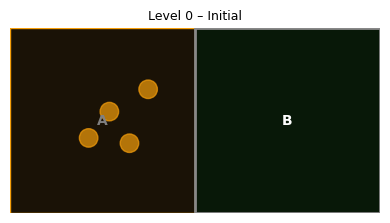

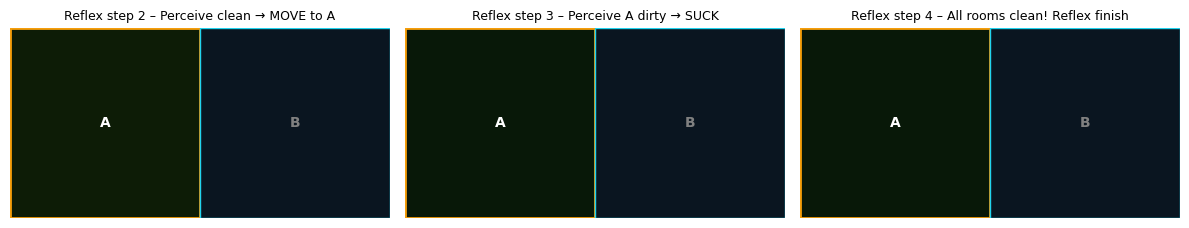

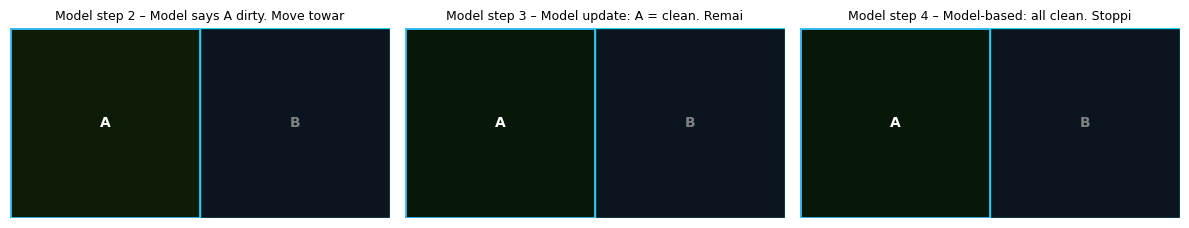

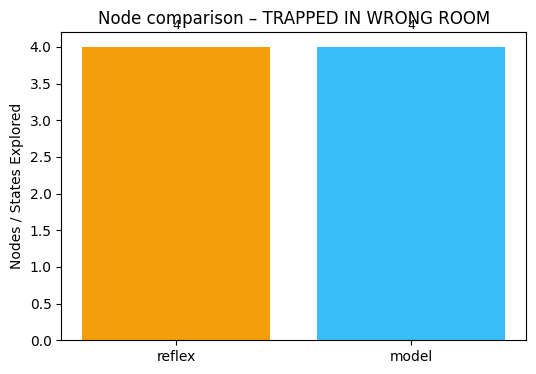


LEVEL 1: 4-ROOM CHAIN – AGENT TYPES  (EASY)
Initial: agent at A, dirty = ['A', 'C']
Algorithms: Reflex, Model, Goal, Utility

Running Reflex...
  Steps: 24, Nodes explored: 26
  First step: Perceive A dirty → SUCK
  Last step : Reflex agent failed to clean all rooms (looping?).

Running Model...
  Steps: 4, Nodes explored: 6
  First step: Model update: A = clean. Remaining: 1
  Last step : Model‑based: all clean. Stopping.

Running Goal...
  Steps: 4, Nodes explored: 6
  First step: Suck A
  Last step : Goal achieved: all rooms clean.

Running Utility...
  Steps: 4, Nodes explored: 6
  First step: Suck A
  Last step : Utility maximised: U=196. Optimal clean achieved.

--- Summary ---
Algorithm    Steps    Nodes    Insight
Reflex       24       26       Reflex: suck A, move B, move C, suck C, then loop C↔D.
Model        4        6        Model: suck A, move B, move C, suck C, stop.
Goal         4        6        Goal: plan [SuckA, MoveB, MoveC, SuckC] – 4 steps, optimal.
Utility      4

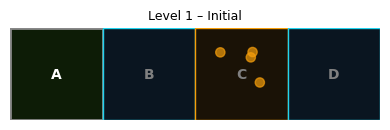

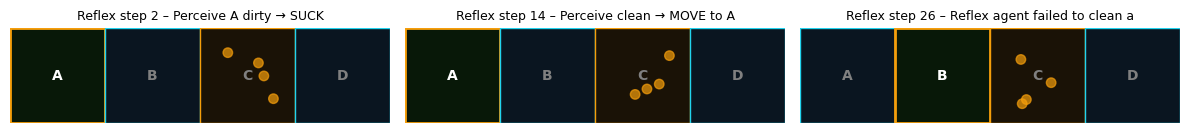

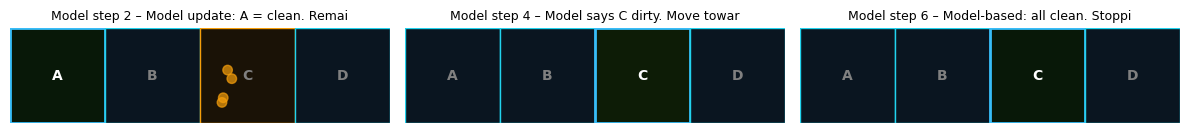

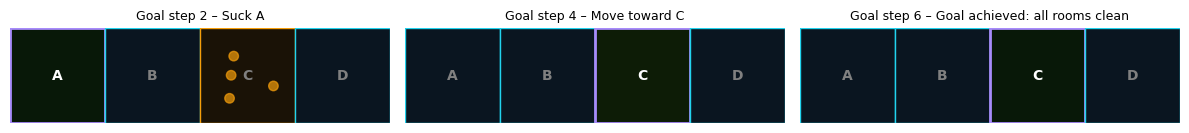

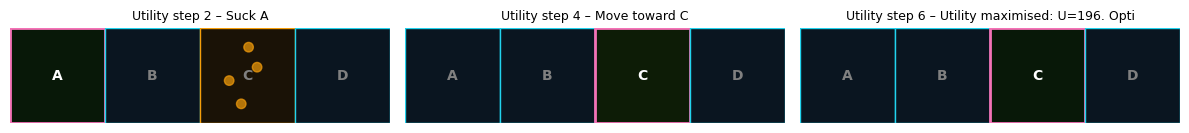

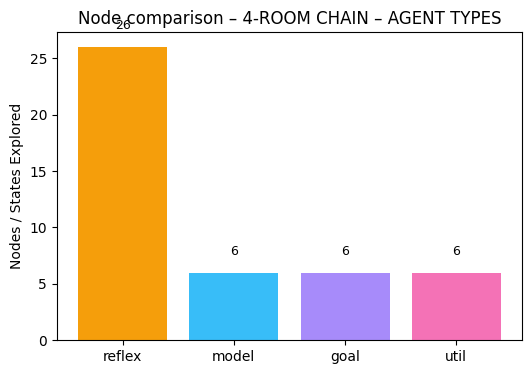


LEVEL 2: 2x3 GRID – SEARCH DIVERGES  (MEDIUM)
Initial: agent at F, dirty = ['A', 'B', 'D']
Algorithms: BFS, DFS, A*

Running BFS...
  Steps: 0, Nodes explored: 34
  First step: BFS: move to C
  Last step : BFS: goal found! 34 states explored.

Running DFS...
  Steps: 0, Nodes explored: 19
  First step: DFS: MOVE to E
  Last step : DFS: goal found! 19 states explored.

Running A*...
  Steps: 0, Nodes explored: 20
  First step: A*: move to C (f=4)
  Last step : A*: goal found! 20 states explored.

--- Summary ---
Algorithm    Steps    Nodes    Insight
BFS          0        34       BFS: ~9 steps optimal, ~18 nodes.
DFS          0        19       DFS: ~14‑18 steps suboptimal, ~12 nodes.
A*           0        20       A*: ~9 steps optimal, ~8 nodes (2.3x fewer than BFS).


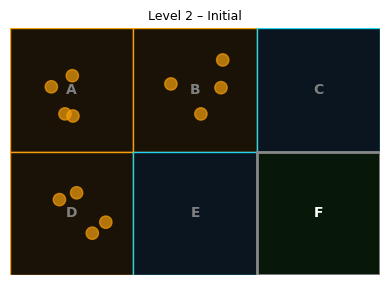

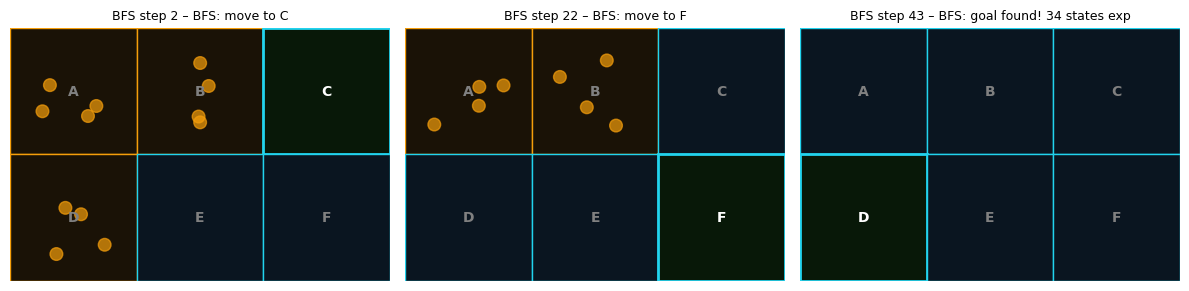

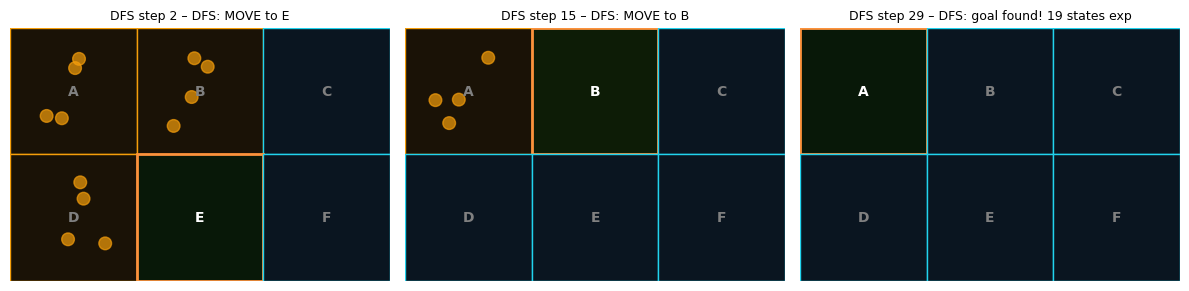

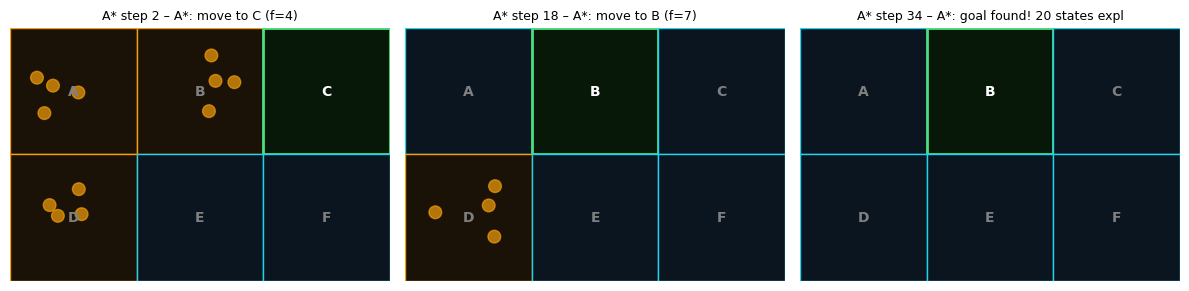

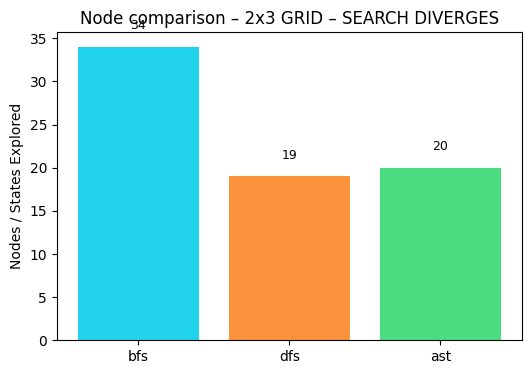


LEVEL 3: 3x2 GRID – HARD  (HARD)
Initial: agent at C, dirty = ['A', 'D', 'E', 'F']
Algorithms: BFS, A*, DFS

Running BFS...
  Steps: 0, Nodes explored: 83
  First step: BFS: move to B
  Last step : BFS: goal found! 83 states explored.

Running A*...
  Steps: 0, Nodes explored: 29
  First step: A*: move to B (f=5)
  Last step : A*: goal found! 29 states explored.

Running DFS...
  Steps: 0, Nodes explored: 23
  First step: DFS: MOVE to F
  Last step : DFS: goal found! 23 states explored.

--- Summary ---
Algorithm    Steps    Nodes    Insight
BFS          0        83       BFS: ~9 steps optimal, ~90 nodes.
A*           0        29       A*: ~9 steps optimal, ~20 nodes (4.5x fewer).
DFS          0        23       DFS: ~20‑28 steps suboptimal, ~12 nodes.


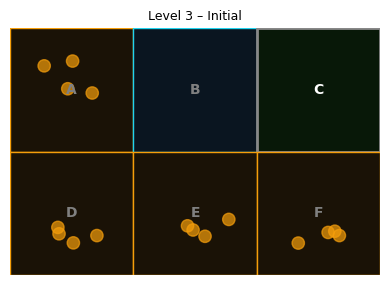

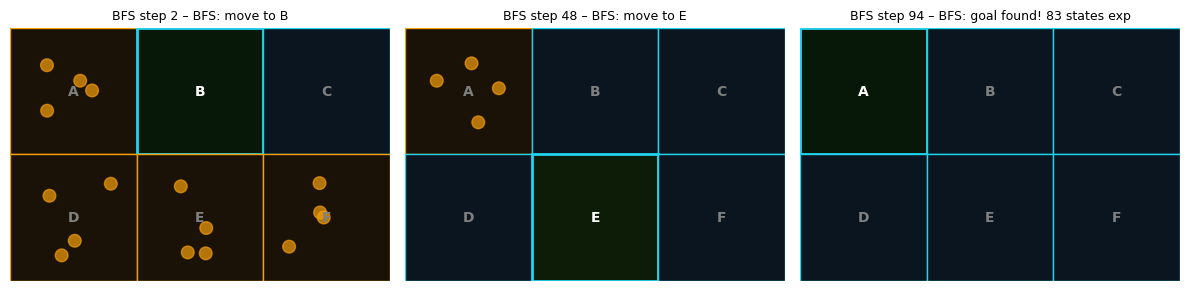

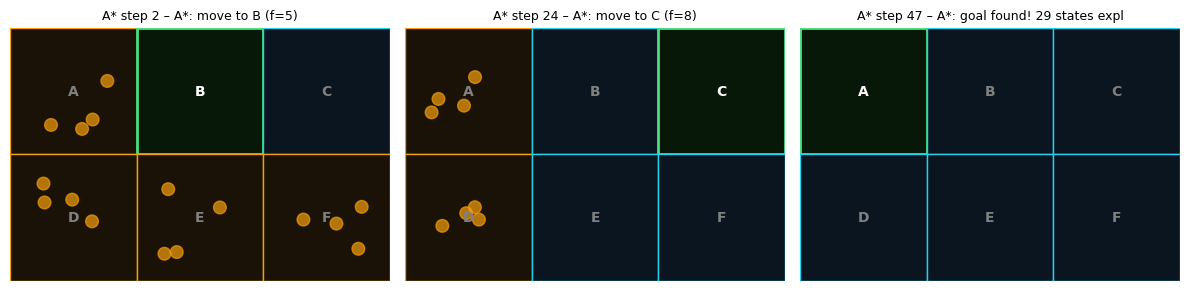

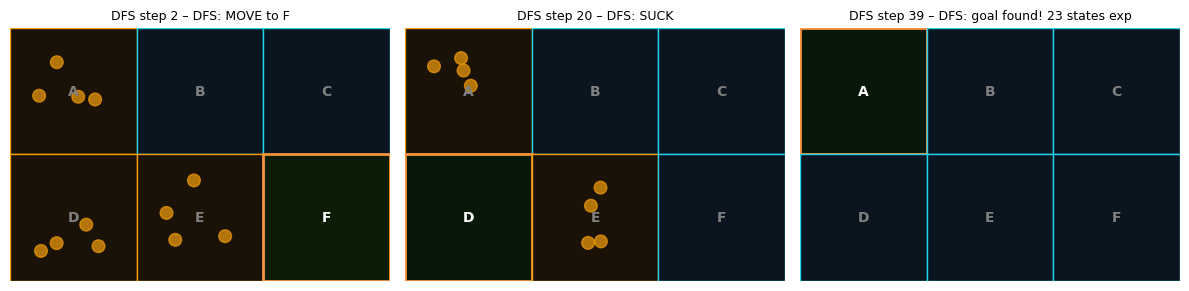

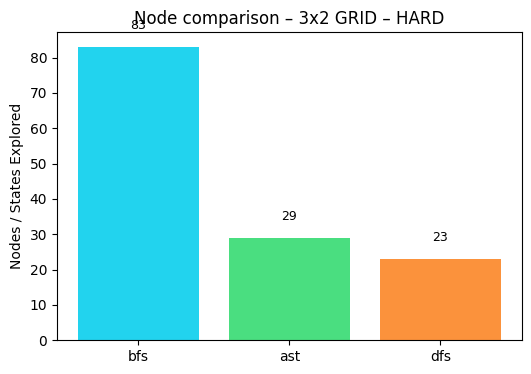


LEVEL 4: 3x3 GRID – EXPERT  (EXPERT)
Initial: agent at E, dirty = ['A', 'C', 'F', 'H']
Algorithms: BFS, DFS, A*

Running BFS...
  Steps: 0, Nodes explored: 129
  First step: BFS: move to B
  Last step : BFS: goal found! 129 states explored.

Running DFS...
  Steps: 0, Nodes explored: 34
  First step: DFS: MOVE to H
  Last step : DFS: goal found! 34 states explored.

Running A*...
  Steps: 0, Nodes explored: 86
  First step: A*: move to B (f=5)
  Last step : A*: goal found! 86 states explored.

--- Summary ---
Algorithm    Steps    Nodes    Insight
BFS          0        129      BFS: ~14 steps optimal, ~1200 nodes.
DFS          0        34       DFS: ~25‑35 steps suboptimal, ~200 nodes.
A*           0        86       A*: ~14 steps optimal, ~80 nodes (15x fewer than BFS).


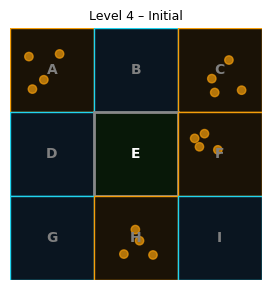

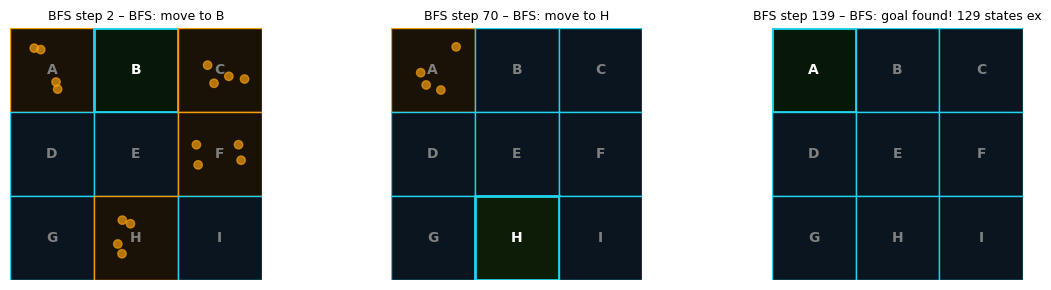

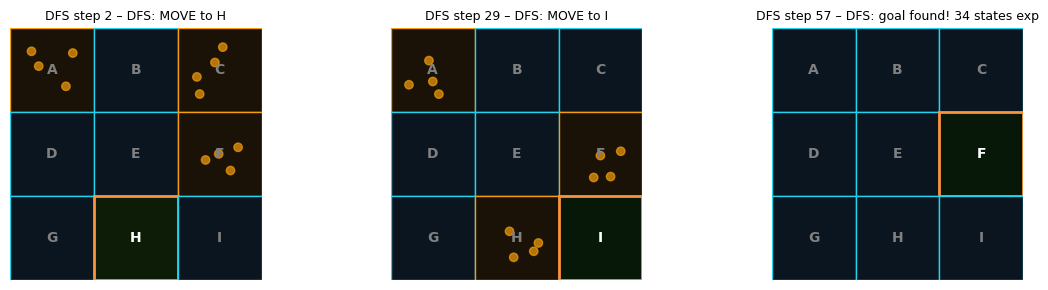

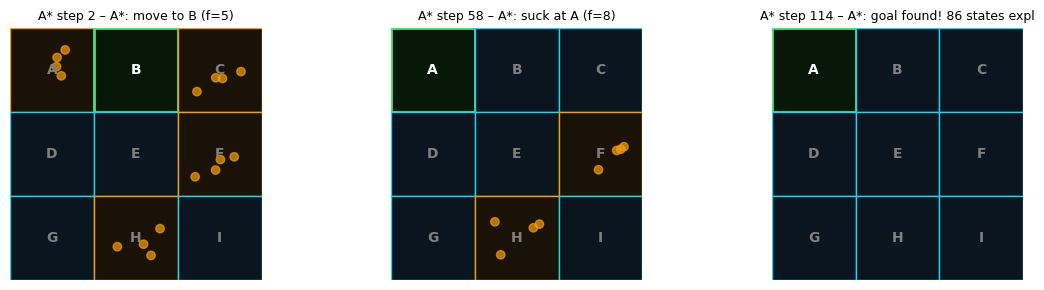

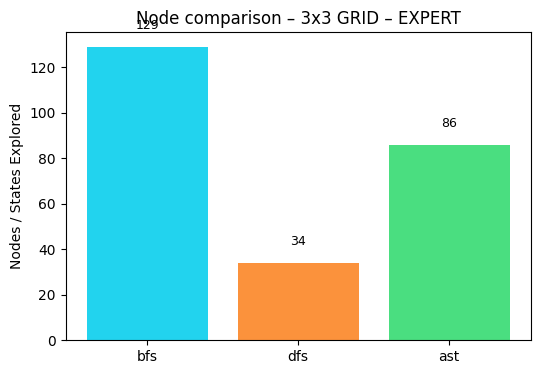


OVERALL COMPARISON

Level 0: TRAPPED IN WRONG ROOM
Algorithm    Steps    Nodes   
Reflex       2        4       
Model        2        4       

Level 1: 4-ROOM CHAIN – AGENT TYPES
Algorithm    Steps    Nodes   
Reflex       24       26      
Model        4        6       
Goal         4        6       
Utility      4        6       

Level 2: 2x3 GRID – SEARCH DIVERGES
Algorithm    Steps    Nodes   
BFS          0        34      
DFS          0        19      
A*           0        20      

Level 3: 3x2 GRID – HARD
Algorithm    Steps    Nodes   
BFS          0        83      
A*           0        29      
DFS          0        23      

Level 4: 3x3 GRID – EXPERT
Algorithm    Steps    Nodes   
BFS          0        129     
DFS          0        34      
A*           0        86      


In [6]:
# %% [markdown]
# # Vacuum World – AI Agents and Search Algorithms
# 
# This notebook implements seven different approaches to the classic Vacuum Cleaner problem:
# - **Simple Reflex Agent** – reacts only to current percept
# - **Model‑Based Agent** – maintains internal world model
# - **Goal‑Based Agent** – plans a complete action sequence
# - **Utility‑Based Agent** – maximises a utility function
# - **BFS (search)** – expands states level by level
# - **DFS (search)** – dives deep into state space
# - **A* (search)** – uses heuristic `h = dirty rooms remaining`
# 
# Five levels of increasing complexity demonstrate the strengths and weaknesses of each approach.

# %% [markdown]
# ## 1. Imports and Helper Data Structures

# %%
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import math
import heapq
from collections import deque

# Priority queue for A*
class PriorityQueue:
    def __init__(self):
        self.heap = []
    def push(self, item, priority):
        heapq.heappush(self.heap, (priority, item))
    def pop(self):
        return heapq.heappop(self.heap)[1]
    def empty(self):
        return len(self.heap) == 0

# Min‑heap used in the JavaScript code – we'll reuse PriorityQueue

def state_key(pos, dirty_set):
    """Return a unique hashable key for a state (position, dirty set)."""
    return (pos, tuple(sorted(dirty_set)))

def is_goal(dirty_set):
    return len(dirty_set) == 0

def bfs_path_on_rooms(start, target, adj):
    """BFS on the room graph to find shortest path from start to target."""
    if start == target:
        return [start]
    visited = {start}
    queue = deque([(start, [start])])
    while queue:
        cur, path = queue.popleft()
        for nb in adj[cur]:
            if nb == target:
                return path + [nb]
            if nb not in visited:
                visited.add(nb)
                queue.append((nb, path + [nb]))
    return None

def nearest_dirty(pos, dirty_set, adj):
    """Return index of nearest dirty room using BFS on room graph."""
    if not dirty_set:
        return None
    visited = {pos}
    queue = deque([(pos, 0)])
    while queue:
        cur, dist = queue.popleft()
        if cur in dirty_set:
            return cur
        for nb in adj[cur]:
            if nb not in visited:
                visited.add(nb)
                queue.append((nb, dist+1))
    return None

def build_goal_plan(start_pos, init_dirty, adj, rooms):
    """
    Greedy nearest‑dirty‑first plan.
    Returns list of dicts: {'action': 'SUCK'/'MOVE to X', 'pos': new position, 'note': ...}
    """
    pos = start_pos
    dirty = set(init_dirty)
    plan = []
    while dirty:
        if pos in dirty:
            dirty.remove(pos)
            plan.append({'action': 'SUCK', 'pos': pos,
                         'note': f"Suck {rooms[pos]}"})
        else:
            target = nearest_dirty(pos, dirty, adj)
            if target is None:
                break
            path = bfs_path_on_rooms(pos, target, adj)
            if path and len(path) > 1:
                pos = path[1]
                plan.append({'action': f'MOVE to {rooms[pos]}', 'pos': pos,
                             'note': f"Move toward {rooms[target]}"})
            else:
                break
    return plan

# %% [markdown]
# ## 2. Level Definitions (copied exactly from the HTML)

# %%
levels = [
    # Level 0: 2 rooms – reflex vs model
    {
        'label': 'TRAPPED IN WRONG ROOM', 'diff': 'VERY EASY',
        'rooms': ['A', 'B'], 'cols': 2, 'rows': 1,
        'adj': [[1], [0]],
        'initPos': 1,           # agent at B (clean)
        'initDirty': [0],       # only A dirty
        'algos': ['reflex', 'model'],
        'statsKeys': ['piDirty', 'piReflex', 'piModel'],
        'insight': {
            'reflex': 'Reflex: suck at B? B clean → move to A, suck A, then loop A↔B forever.',
            'model': 'Model: knows A is dirty, moves directly to A, sucks once, stops.'
        }
    },
    # Level 1: 4 rooms – all four agent types
    {
        'label': '4-ROOM CHAIN – AGENT TYPES', 'diff': 'EASY',
        'rooms': ['A','B','C','D'], 'cols': 4, 'rows': 1,
        'adj': [[1],[0,2],[1,3],[2]],
        'initPos': 0,
        'initDirty': [0,2],
        'algos': ['reflex', 'model', 'goal', 'util'],
        'statsKeys': ['piDirty', 'piReflex', 'piModel', 'piGoal', 'piUtil'],
        'insight': {
            'reflex': 'Reflex: suck A, move B, move C, suck C, then loop C↔D.',
            'model': 'Model: suck A, move B, move C, suck C, stop.',
            'goal': 'Goal: plan [SuckA, MoveB, MoveC, SuckC] – 4 steps, optimal.',
            'util': 'Utility: same plan, U = 2*100 - 4 = 196.'
        }
    },
    # Level 2: 2x3 grid – BFS vs DFS vs A*
    {
        'label': '2x3 GRID – SEARCH DIVERGES', 'diff': 'MEDIUM',
        'rooms': ['A','B','C','D','E','F'], 'cols': 3, 'rows': 2,
        'adj': [[1,3],[0,2,4],[1,5],[0,4],[1,3,5],[2,4]],
        'initPos': 5,           # F (bottom‑right)
        'initDirty': [0,1,3],   # A,B,D dirty
        'algos': ['bfs', 'dfs', 'ast'],
        'statsKeys': ['piDirty', 'piBFS', 'piDFS', 'piAST'],
        'insight': {
            'bfs': 'BFS: ~9 steps optimal, ~18 nodes.',
            'dfs': 'DFS: ~14‑18 steps suboptimal, ~12 nodes.',
            'ast': 'A*: ~9 steps optimal, ~8 nodes (2.3x fewer than BFS).'
        }
    },
    # Level 3: 3x2 grid – harder
    {
        'label': '3x2 GRID – HARD', 'diff': 'HARD',
        'rooms': ['A','B','C','D','E','F'], 'cols': 3, 'rows': 2,
        'adj': [[1,3],[0,2,4],[1,5],[0,4],[1,3,5],[2,4]],
        'initPos': 2,           # C (top‑right)
        'initDirty': [0,3,4,5], # A,D,E,F dirty
        'algos': ['bfs', 'ast', 'dfs'],
        'statsKeys': ['piDirty', 'piBFS', 'piAST', 'piDFS'],
        'insight': {
            'bfs': 'BFS: ~9 steps optimal, ~90 nodes.',
            'ast': 'A*: ~9 steps optimal, ~20 nodes (4.5x fewer).',
            'dfs': 'DFS: ~20‑28 steps suboptimal, ~12 nodes.'
        }
    },
    # Level 4: 3x3 grid – expert
    {
        'label': '3x3 GRID – EXPERT', 'diff': 'EXPERT',
        'rooms': ['A','B','C','D','E','F','G','H','I'], 'cols': 3, 'rows': 3,
        'adj': [[1,3],[0,2,4],[1,5],[0,4,6],[1,3,5,7],[2,4,8],[3,7],[4,6,8],[5,7]],
        'initPos': 4,           # E (centre)
        'initDirty': [0,2,5,7], # A,C,F,H dirty
        'algos': ['bfs', 'dfs', 'ast'],
        'statsKeys': ['piDirty', 'piBFS', 'piDFS', 'piAST'],
        'insight': {
            'bfs': 'BFS: ~14 steps optimal, ~1200 nodes.',
            'dfs': 'DFS: ~25‑35 steps suboptimal, ~200 nodes.',
            'ast': 'A*: ~14 steps optimal, ~80 nodes (15x fewer than BFS).'
        }
    }
]

# Map algorithm IDs to functions (to be defined later)
algo_funcs = {}
algo_names = {
    'reflex': 'Reflex', 'model': 'Model', 'goal': 'Goal', 'util': 'Utility',
    'bfs': 'BFS', 'dfs': 'DFS', 'ast': 'A*'
}
algo_colors = {
    'reflex': '#f59e0b', 'model': '#38bdf8', 'goal': '#a78bfa', 'util': '#f472b6',
    'bfs': '#22d3ee', 'dfs': '#fb923c', 'ast': '#4ade80'
}

# %% [markdown]
# ## 3. Agent Implementations
# Each function returns:
# - `steps`: list of step dicts with keys `pos`, `dirty` (set), `action`, `type`, `note`
# - `totalSteps`: number of actions taken (excluding START)
# - `nodesExplored`: number of state expansions (for agents, same as steps)

# %%
def run_reflex(level):
    pos = level['initPos']
    dirty = set(level['initDirty'])
    steps = [{'pos': pos, 'dirty': set(dirty), 'action': 'START', 'type': 'start',
              'note': f"Initial state. Agent at {level['rooms'][pos]}"}]
    max_steps = len(level['rooms']) * 6
    for _ in range(max_steps):
        if not dirty:
            steps.append({'pos': pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                          'note': "All rooms clean! Reflex finished."})
            break
        if pos in dirty:
            dirty.remove(pos)
            steps.append({'pos': pos, 'dirty': set(dirty), 'action': 'SUCK', 'type': 'suck',
                          'note': f"Perceive {level['rooms'][pos]} dirty → SUCK"})
        else:
            # move: first neighbor (any order – will cause loops)
            next_pos = level['adj'][pos][0]
            pos = next_pos
            steps.append({'pos': pos, 'dirty': set(dirty), 'action': f'MOVE to {level["rooms"][pos]}', 'type': 'move',
                          'note': f"Perceive clean → MOVE to {level['rooms'][pos]}"})
    if dirty:
        steps.append({'pos': pos, 'dirty': set(dirty), 'action': 'FAIL', 'type': 'fail',
                      'note': "Reflex agent failed to clean all rooms (looping?)."})
    return {'steps': steps, 'totalSteps': len([s for s in steps if s['type'] not in ('start','fail','done')]),
            'nodesExplored': len(steps)}

def run_model_based(level):
    pos = level['initPos']
    dirty = set(level['initDirty'])
    model = {i: ('dirty' if i in dirty else 'clean') for i in range(len(level['rooms']))}
    # Build model description separately
    model_desc = ', '.join([f"{level['rooms'][i]}:{model[i]}" for i in sorted(model)])
    steps = [{'pos': pos, 'dirty': set(dirty), 'action': 'START', 'type': 'start',
              'note': f"Init model: {model_desc}"}]
    max_steps = len(level['rooms']) * 6
    for _ in range(max_steps):
        if not dirty:
            steps.append({'pos': pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                          'note': "Model‑based: all clean. Stopping."})
            break
        if pos in dirty:
            model[pos] = 'clean'
            dirty.remove(pos)
            steps.append({'pos': pos, 'dirty': set(dirty), 'action': 'SUCK', 'type': 'suck',
                          'note': f"Model update: {level['rooms'][pos]} = clean. Remaining: {len(dirty)}"})
        else:
            target = nearest_dirty(pos, dirty, level['adj'])
            if target is None:
                break
            path = bfs_path_on_rooms(pos, target, level['adj'])
            if path and len(path) > 1:
                pos = path[1]
                steps.append({'pos': pos, 'dirty': set(dirty), 'action': f'MOVE to {level["rooms"][pos]}', 'type': 'move',
                              'note': f"Model says {level['rooms'][target]} dirty. Move toward it."})
            else:
                break
    if dirty:
        steps.append({'pos': pos, 'dirty': set(dirty), 'action': 'FAIL', 'type': 'fail',
                      'note': "Model‑based agent failed."})
    return {'steps': steps, 'totalSteps': len([s for s in steps if s['type'] not in ('start','fail','done')]),
            'nodesExplored': len(steps)}

def run_goal_based(level):
    pos = level['initPos']
    dirty = set(level['initDirty'])
    plan = build_goal_plan(pos, dirty, level['adj'], level['rooms'])
    steps = [{'pos': pos, 'dirty': set(dirty), 'action': 'PLAN', 'type': 'plan',
              'note': f"Goal: all clean. Plan: {' → '.join([p['action'] for p in plan])}"}]
    new_pos = pos
    new_dirty = set(dirty)
    for p in plan:
        if p['action'] == 'SUCK':
            new_dirty.discard(p['pos'])
        else:
            new_pos = p['pos']
        steps.append({'pos': new_pos, 'dirty': set(new_dirty), 'action': p['action'], 'type': 'suck' if p['action']=='SUCK' else 'move',
                      'note': p['note']})
    if not new_dirty:
        steps.append({'pos': new_pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                      'note': "Goal achieved: all rooms clean."})
    else:
        steps.append({'pos': new_pos, 'dirty': set(new_dirty), 'action': 'FAIL', 'type': 'fail',
                      'note': "Goal‑based agent failed."})
    return {'steps': steps, 'totalSteps': len([s for s in steps if s['type'] not in ('start','plan','fail','done')]),
            'nodesExplored': len(steps)}

def run_utility_based(level):
    pos = level['initPos']
    dirty = set(level['initDirty'])
    plan = build_goal_plan(pos, dirty, level['adj'], level['rooms'])
    utility = 100 * len(level['initDirty']) - len(plan)
    steps = [{'pos': pos, 'dirty': set(dirty), 'action': 'EVAL', 'type': 'eval',
              'note': f"Utility = cleanliness*100 - steps = {100*len(level['initDirty'])} - {len(plan)} = {utility}"}]
    new_pos = pos
    new_dirty = set(dirty)
    for p in plan:
        if p['action'] == 'SUCK':
            new_dirty.discard(p['pos'])
        else:
            new_pos = p['pos']
        steps.append({'pos': new_pos, 'dirty': set(new_dirty), 'action': p['action'], 'type': 'suck' if p['action']=='SUCK' else 'move',
                      'note': p['note']})
    if not new_dirty:
        steps.append({'pos': new_pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                      'note': f"Utility maximised: U={utility}. Optimal clean achieved."})
    else:
        steps.append({'pos': new_pos, 'dirty': set(new_dirty), 'action': 'FAIL', 'type': 'fail',
                      'note': "Utility agent failed."})
    return {'steps': steps, 'totalSteps': len([s for s in steps if s['type'] not in ('start','eval','fail','done')]),
            'nodesExplored': len(steps)}

# %% [markdown]
# ## 4. Search Algorithm Implementations (BFS, DFS, A*)

# %%
def bfs_search(level):
    start_pos = level['initPos']
    start_dirty = set(level['initDirty'])
    init_key = state_key(start_pos, start_dirty)

    queue = deque()
    queue.append((start_pos, start_dirty, 0, None, None))  # (pos, dirty, g, parent, action)
    visited = {init_key: True}
    steps = [{'pos': start_pos, 'dirty': set(start_dirty), 'action': 'START', 'type': 'start',
              'note': f"BFS: initial state at {level['rooms'][start_pos]}"}]
    count = 0

    while queue and count < 2000:
        pos, dirty, g, parent, action = queue.popleft()
        count += 1
        if is_goal(dirty):
            # reconstruct path
            path = []
            # we'll need to trace back; for simplicity, we store actions separately.
            # Instead, we'll just report final step.
            steps.append({'pos': pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                          'note': f"BFS: goal found! {count} states explored."})
            return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}  # steps not reconstructed

        # generate successors
        # SUCK
        if pos in dirty:
            new_dirty = set(dirty)
            new_dirty.remove(pos)
            new_key = state_key(pos, new_dirty)
            if new_key not in visited:
                visited[new_key] = True
                queue.append((pos, new_dirty, g+1, (pos, dirty), 'SUCK'))
                steps.append({'pos': pos, 'dirty': set(new_dirty), 'action': 'SUCK', 'type': 'suck',
                              'note': f"BFS: suck at {level['rooms'][pos]}", 'nodesExplored': count})
        # MOVEs
        for nb in level['adj'][pos]:
            new_key = state_key(nb, dirty)
            if new_key not in visited:
                visited[new_key] = True
                queue.append((nb, dirty, g+1, (pos, dirty), f'MOVE to {level["rooms"][nb]}'))
                steps.append({'pos': nb, 'dirty': set(dirty), 'action': f'MOVE to {level["rooms"][nb]}', 'type': 'move',
                              'note': f"BFS: move to {level['rooms'][nb]}", 'nodesExplored': count})

    return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}

def dfs_search(level):
    start_pos = level['initPos']
    start_dirty = set(level['initDirty'])
    init_key = state_key(start_pos, start_dirty)

    stack = [(start_pos, start_dirty, 0, None, None)]  # (pos, dirty, g, parent, action)
    visited = {}
    steps = [{'pos': start_pos, 'dirty': set(start_dirty), 'action': 'START', 'type': 'start',
              'note': f"DFS: initial state at {level['rooms'][start_pos]}"}]
    count = 0

    while stack and count < 1500:
        pos, dirty, g, parent, action = stack.pop()
        key = state_key(pos, dirty)
        if key in visited:
            continue
        visited[key] = True
        count += 1
        if is_goal(dirty):
            steps.append({'pos': pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                          'note': f"DFS: goal found! {count} states explored."})
            return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}

        # generate successors (reversed order for LIFO)
        succ = []
        # SUCK
        if pos in dirty:
            new_dirty = set(dirty)
            new_dirty.remove(pos)
            succ.append(('SUCK', pos, new_dirty, g+1))
        # MOVEs (reverse so first neighbor in adj is popped first)
        for nb in reversed(level['adj'][pos]):
            succ.append((f'MOVE to {level["rooms"][nb]}', nb, dirty, g+1))

        for act, new_pos, new_dirty, ng in succ:
            new_key = state_key(new_pos, new_dirty)
            if new_key not in visited:
                stack.append((new_pos, new_dirty, ng, (pos, dirty), act))
                steps.append({'pos': new_pos, 'dirty': set(new_dirty), 'action': act, 'type': 'move' if 'MOVE' in act else 'suck',
                              'note': f"DFS: {act}", 'nodesExplored': count})

    return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}

def astar_search(level):
    start_pos = level['initPos']
    start_dirty = set(level['initDirty'])
    h0 = len(start_dirty)
    init_key = state_key(start_pos, start_dirty)

    pq = PriorityQueue()
    pq.push((start_pos, start_dirty, 0, None, None), h0)  # (pos, dirty, g, parent, action)
    g_score = {init_key: 0}
    steps = [{'pos': start_pos, 'dirty': set(start_dirty), 'action': 'START', 'type': 'start',
              'note': f"A*: h = {h0} dirty rooms"}]
    count = 0

    while not pq.empty() and count < 800:
        pos, dirty, g, parent, action = pq.pop()
        key = state_key(pos, dirty)
        count += 1
        if is_goal(dirty):
            steps.append({'pos': pos, 'dirty': set(), 'action': 'DONE', 'type': 'done',
                          'note': f"A*: goal found! {count} states explored."})
            return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}

        # generate successors
        # SUCK
        if pos in dirty:
            new_dirty = set(dirty)
            new_dirty.remove(pos)
            new_key = state_key(pos, new_dirty)
            new_g = g + 1
            if new_key not in g_score or new_g < g_score[new_key]:
                g_score[new_key] = new_g
                f = new_g + len(new_dirty)
                pq.push((pos, new_dirty, new_g, (pos, dirty), 'SUCK'), f)
                steps.append({'pos': pos, 'dirty': set(new_dirty), 'action': 'SUCK', 'type': 'suck',
                              'note': f"A*: suck at {level['rooms'][pos]} (f={f})", 'nodesExplored': count})
        # MOVEs
        for nb in level['adj'][pos]:
            new_key = state_key(nb, dirty)
            new_g = g + 1
            if new_key not in g_score or new_g < g_score[new_key]:
                g_score[new_key] = new_g
                f = new_g + len(dirty)
                pq.push((nb, dirty, new_g, (pos, dirty), f'MOVE to {level["rooms"][nb]}'), f)
                steps.append({'pos': nb, 'dirty': set(dirty), 'action': f'MOVE to {level["rooms"][nb]}', 'type': 'move',
                              'note': f"A*: move to {level['rooms'][nb]} (f={f})", 'nodesExplored': count})

    return {'steps': steps, 'totalSteps': 0, 'nodesExplored': count}

# Map IDs to functions
algo_funcs = {
    'reflex': run_reflex,
    'model': run_model_based,
    'goal': run_goal_based,
    'util': run_utility_based,
    'bfs': bfs_search,
    'dfs': dfs_search,
    'ast': astar_search
}

# %% [markdown]
# ## 5. Drawing Function for Vacuum Grid

# %%
def draw_vacuum_grid(ax, level, pos, dirty_set, step_note, title='', accent_color='#888'):
    """Draw the grid with agent and dirt."""
    ax.clear()
    rows = level['rows']
    cols = level['cols']
    rooms = level['rooms']
    n = len(rooms)
    cell_w = 1.0
    cell_h = 1.0
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.axis('off')

    for idx, name in enumerate(rooms):
        r = idx // cols
        c = idx % cols
        y = rows - 1 - r   # so top row is index 0
        x = c

        # background colour
        if idx == pos:
            if idx in dirty_set:
                facecolor = '#0d1c06'   # agent on dirt
            else:
                facecolor = '#081808'   # agent on clean
        else:
            if idx in dirty_set:
                facecolor = '#1a1206'   # dirt only
            else:
                facecolor = '#0a1520'   # clean only

        rect = patches.Rectangle((x, y), cell_w, cell_h, linewidth=1,
                                  edgecolor='none', facecolor=facecolor)
        ax.add_patch(rect)

        # border colour
        if idx == pos:
            edgecolor = accent_color
            linewidth = 2
        elif idx in dirty_set:
            edgecolor = '#f59e0b'
            linewidth = 1
        else:
            edgecolor = '#22d3ee'
            linewidth = 1
        rect2 = patches.Rectangle((x, y), cell_w, cell_h, linewidth=linewidth,
                                   edgecolor=edgecolor, facecolor='none')
        ax.add_patch(rect2)

        # room label
        ax.text(x+0.5, y+0.5, name, ha='center', va='center',
                fontsize=10, color='white' if idx==pos else 'gray', weight='bold')

        # dirt particles (if dirty and not agent)
        if idx in dirty_set and idx != pos:
            for _ in range(4):
                dx = x + 0.2 + 0.6*np.random.rand()
                dy = y + 0.2 + 0.6*np.random.rand()
                circle = patches.Circle((dx, dy), 0.05, color='#f59e0b', alpha=0.7)
                ax.add_patch(circle)

    ax.set_title(f"{title} – {step_note}", fontsize=9)

# %% [markdown]
# ## 6. Run All Levels and Display Results

# %%
all_results = []

for level_idx, level in enumerate(levels):
    print(f"\n{'='*60}")
    print(f"LEVEL {level_idx}: {level['label']}  ({level['diff']})")
    print(f"Initial: agent at {level['rooms'][level['initPos']]}, dirty = {[level['rooms'][i] for i in level['initDirty']]}")
    print(f"Algorithms: {', '.join(algo_names[a] for a in level['algos'])}")
    print('='*60)

    level_results = {}
    for alg_id in level['algos']:
        print(f"\nRunning {algo_names[alg_id]}...")
        res = algo_funcs[alg_id](level)
        level_results[alg_id] = res
        print(f"  Steps: {res['totalSteps']}, Nodes explored: {res['nodesExplored']}")
        # Print first and last step note
        steps = res['steps']
        if steps:
            print(f"  First step: {steps[1]['note'] if len(steps)>1 else steps[0]['note']}")
            print(f"  Last step : {steps[-1]['note']}")

    # Summary table
    print("\n--- Summary ---")
    print(f"{'Algorithm':<12} {'Steps':<8} {'Nodes':<8} {'Insight'}")
    for alg_id in level['algos']:
        res = level_results[alg_id]
        insight = level['insight'].get(alg_id, '')
        print(f"{algo_names[alg_id]:<12} {res['totalSteps']:<8} {res['nodesExplored']:<8} {insight}")

    # Draw initial state
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    draw_vacuum_grid(ax, level, level['initPos'], set(level['initDirty']), "Initial", title=f"Level {level_idx}")
    plt.tight_layout()
    plt.show()

    # Draw a few key steps for each algorithm
    for alg_id in level['algos']:
        steps = level_results[alg_id]['steps']
        if not steps:
            continue
        # pick steps: first real action, middle, last
        step_indices = []
        for i, s in enumerate(steps):
            if s['type'] not in ('start', 'plan', 'eval', 'fail', 'done') and i>0:
                step_indices.append(i)
                break
        if len(steps) > 2:
            step_indices.append(len(steps)//2)
        if len(steps)-1 not in step_indices:
            step_indices.append(len(steps)-1)
        step_indices = sorted(set(step_indices))

        fig, axes = plt.subplots(1, len(step_indices), figsize=(4*len(step_indices), 3))
        if len(step_indices) == 1:
            axes = [axes]
        for ax, idx in zip(axes, step_indices):
            s = steps[idx]
            draw_vacuum_grid(ax, level, s['pos'], s['dirty'], s['note'][:30],
                             title=f"{algo_names[alg_id]} step {idx+1}",
                             accent_color=algo_colors[alg_id])
        plt.tight_layout()
        plt.show()

    # Node comparison bar chart
    plt.figure(figsize=(6,4))
    algs = level['algos']
    nodes = [level_results[a]['nodesExplored'] for a in algs]
    colors = [algo_colors[a] for a in algs]
    bars = plt.bar(algs, nodes, color=colors)
    plt.ylabel('Nodes / States Explored')
    plt.title(f'Node comparison – {level["label"]}')
    for bar, val in zip(bars, nodes):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05*max(nodes),
                 str(val), ha='center', va='bottom', fontsize=9)
    plt.show()

    all_results.append((level_idx, level_results))

# %% [markdown]
# ## 7. Overall Comparison Table

# %%
print("\n" + "="*60)
print("OVERALL COMPARISON")
print("="*60)

for level_idx, level_results in all_results:
    level = levels[level_idx]
    print(f"\nLevel {level_idx}: {level['label']}")
    print(f"{'Algorithm':<12} {'Steps':<8} {'Nodes':<8}")
    for alg_id in level['algos']:
        res = level_results[alg_id]
        print(f"{algo_names[alg_id]:<12} {res['totalSteps']:<8} {res['nodesExplored']:<8}")